# Descriptives: ULT freezers
This notebook creates statistics about ult freezers.

In [1]:
# Set up
import pandas as pd
import numpy as np
import sys
from pathlib import Path
CODE_ROOT = Path.cwd().parents[1]
sys.path.append(str(CODE_ROOT))
import config
from openpyxl import Workbook
from openpyxl.styles import Alignment
import os
import matplotlib.pyplot as plt

In [2]:
# Plot settings
# Color palette
poster_main = "#5DAE4A"
poster_accent = "#0E2F4F"
poster_edge = "#2F6E24"
poster_text = "#382424"

# Plot typography
plot_font = "Arial"
plt.rcParams["font.family"] = plot_font
plt.rcParams["font.size"] = 13

# Set font sizes
axis_title_size = 17
tick_label_size = 15

output_folder = config.OUTPUT / "2_Histograms"
output_folder.mkdir(parents=True, exist_ok=True)

In [3]:
# Load data
labs = pd.read_csv(
    config.PROCESSED_DATA / "individual_processed_4.csv",
    keep_default_na=False,  # Keep "None" as a string, not NaN
    na_values=[""] # Only treat empty strings as NaN
)
equipment = pd.read_csv(
    config.PROCESSED_DATA / "panel_processed_2.csv",
    keep_default_na=False,  # Keep "None" as a string, not NaN
    na_values=[""] # Only treat empty strings as NaN
)

In [4]:
# Keep only equipment where equipment = ult and survey = BL
equipment = equipment[(equipment["equipment"] == "ult") & (equipment["survey"] == "BL")]

In [5]:
# Count the number of distinct labgroupids
num_labgroups = equipment["labgroupid"].nunique()
print(f"Number of lab groups with ults: {num_labgroups}")
prop_ults = num_labgroups / labs["labgroupid"].nunique()
print(f"Proportion of lab groups with ults: {prop_ults:.0%}")

Number of lab groups with ults: 55
Proportion of lab groups with ults: 40%


In [6]:
# Parse numeric values safely
equipment["number"] = pd.to_numeric(equipment["number"], errors="coerce")
equipment["temp_ult"] = pd.to_numeric(equipment["temp_ult"], errors="coerce")

# Keep valid rows with positive counts
equipment = equipment.dropna(subset=["temp_ult", "number"])
equipment = equipment[equipment["number"] > 0]

# Create categorical variable for ULT temperature categories
equipment["temp_cat"] = np.select(
    [
        equipment["temp_ult"] == -70,
        (equipment["temp_ult"] < -70) & (equipment["temp_ult"] > -80),
        equipment["temp_ult"] <= -80,
    ],
    [
        "-70°C",
        "-79°C to -71°C",
        "-80°C or lower",
    ],
    default="Other",
 )

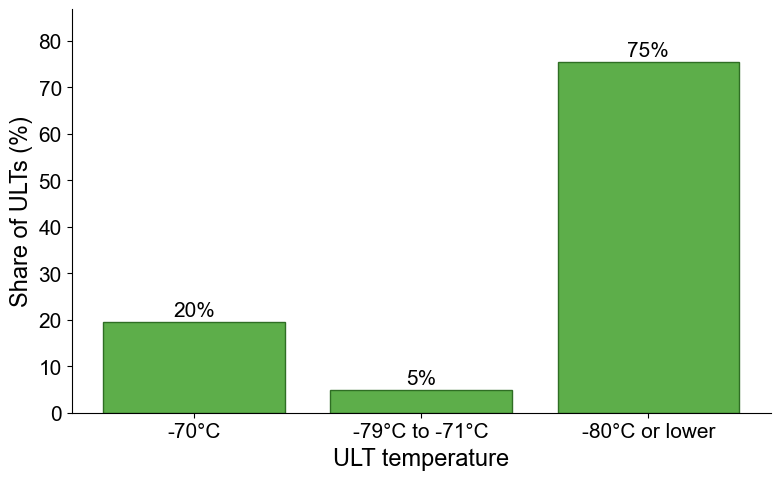

In [7]:
# Weighted distribution of ULT temperatures by category (weighted by number of units)
required_cols = ["temp_cat", "number"]
missing = [c for c in required_cols if c not in equipment.columns]
if missing:
    raise KeyError(f"Missing required columns in equipment: {missing}")

temp_plot = equipment[required_cols].copy()

cat_order = ["-70°C", "-79°C to -71°C", "-80°C or lower"]
temp_cat_dist = (
    temp_plot[temp_plot["temp_cat"] != "Other"]
    .groupby("temp_cat", as_index=False)["number"]
    .sum()
 )

temp_cat_dist["temp_cat"] = pd.Categorical(
    temp_cat_dist["temp_cat"], categories=cat_order, ordered=True
)
temp_cat_dist = temp_cat_dist.sort_values("temp_cat")

total_ults = temp_cat_dist["number"].sum()
temp_cat_dist["pct_ults"] = 100 * temp_cat_dist["number"] / total_ults

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(
    temp_cat_dist["temp_cat"],
    temp_cat_dist["pct_ults"],
    color=poster_main,
    edgecolor=poster_edge
 )

ax.set_xlabel("ULT temperature", fontsize=axis_title_size)
ax.set_ylabel("Share of ULTs (%)", fontsize=axis_title_size)
ax.set_ylim(0, max(temp_cat_dist["pct_ults"].max() * 1.15, 5))
ax.tick_params(axis="x", labelsize=tick_label_size, rotation=0)
ax.tick_params(axis="y", labelsize=tick_label_size)

# Keep only axis lines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for i, v in enumerate(temp_cat_dist["pct_ults"]):
    ax.text(i, v + 0.4, f"{v:.0f}%", ha="center", va="bottom", fontsize=tick_label_size)

plt.tight_layout()
plt.show()

In [8]:
# Print weighted counts and percentages by ULT temperature category
temp_cat_table = temp_cat_dist.copy()
temp_cat_table = temp_cat_table.rename(columns={"number": "count_ults", "pct_ults": "percent_ults"})
temp_cat_table["count_ults"] = temp_cat_table["count_ults"].astype(int)
temp_cat_table["percent_ults"] = temp_cat_table["percent_ults"].round(1)

print("Weighted ULT temperature distribution (count and %):")
print(temp_cat_table.to_string(index=False))

Weighted ULT temperature distribution (count and %):
      temp_cat  count_ults  percent_ults
         -70°C          20          19.6
-79°C to -71°C           5           4.9
-80°C or lower          77          75.5


In [9]:
# Merge with the labs dataset
equipment = equipment.merge(labs[[
    "labgroupid", "calc_ult_energy", 
    "calc_ult_co2", "calc_total_energy", 
    "calc_total_co2"]], 
    on="labgroupid", how="left")


In [10]:
# Calculate potential CO2 savings (assuming all -80 ULTs could be replaced by -70 ULTs and that replacing would result in -28% energy use)
equipment["potential_co2_savings"] = np.where(
    equipment["temp_cat"] == "-80°C or lower",
    equipment["calc_ult_co2"] * 0.28,
    0
)

# Sum over all the potential CO2 savings to get total potential savings
total_potential_co2_savings = equipment["potential_co2_savings"].sum()
print(f"Total potential CO2 savings from replacing -80°C ULTs with -70 ULTs: {total_potential_co2_savings:.0f} tCO2e")

# What is this as a percentage of total ULT CO2 emissions?
total_ult_co2 = equipment["calc_ult_co2"].sum()
potential_savings_pct = 100 * total_potential_co2_savings / total_ult_co2
print(f"Potential CO2 savings as a percentage of total ULT CO2 emissions: {potential_savings_pct:.0f}%")

# Calculate potential savings per lab group (conditional on having at least one -80°C ULT)
lab_savings = equipment.groupby("labgroupid").apply(
    lambda df: df.loc[df["temp_cat"] == "-80°C or lower", "potential_co2_savings"].sum()
).reset_index(name="potential_co2_savings")
lab_savings = lab_savings[lab_savings["potential_co2_savings"] > 0]

# Average potential savings per lab group with at least one -80°C ULT
avg_savings_per_lab = lab_savings["potential_co2_savings"].mean()
print(f"Average potential savings per lab group: {avg_savings_per_lab:.3f} tCO2e")

# What are these potential savings as a percentage of total CO2 emissions per lab group?
lab_savings = lab_savings.merge(
    labs[["labgroupid", "calc_total_co2"]],
    on="labgroupid", how="left"
)

lab_savings["potential_savings_pct"] = 100 * lab_savings["potential_co2_savings"] / lab_savings["calc_total_co2"]
avg_savings_pct_per_lab = lab_savings["potential_savings_pct"].mean()
print(f"Average potential savings as a percentage of total CO2 emissions per lab group: {avg_savings_pct_per_lab:.0f}%")

Total potential CO2 savings from replacing -80°C ULTs with -70 ULTs: 19 tCO2e
Potential CO2 savings as a percentage of total ULT CO2 emissions: 24%
Average potential savings per lab group: 0.434 tCO2e
Average potential savings as a percentage of total CO2 emissions per lab group: 10%


/var/folders/nn/21zflm3n7gzc5spw42wq352rpm87xt/T/ipykernel_33865/4124915917.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  lab_savings = equipment.groupby("labgroupid").apply(
